Praktikum kali ini anda diminta menggunakan dataset breast cancer yang bisa diunduh menggunakan kaggle API dari: https://www.kaggle.com/forderation/breakhis-400x


### **1. Load Data**

In [1]:
from google.colab import files
files.upload()

{}

In [2]:
!mkdir -p ~/.kaggle #membuat directory bernama kaggle
!cp kaggle.json ~/.kaggle/ #copy file kaggle.json upload tadi ke directory baru
!chmod 600 ~/.kaggle/kaggle.json #berikan izin untuk file kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [3]:
#Unduh dataset
!kaggle datasets download -d forderation/breakhis-400x

Dataset URL: https://www.kaggle.com/datasets/forderation/breakhis-400x
License(s): CC0-1.0
100% 803M/803M [00:07<00:00, 119MB/s]



In [4]:
#ekstraksi zip
from zipfile import ZipFile
file_name = "breakhis-400x.zip"

with ZipFile(file_name,'r') as zip :
  zip.extractall()
  print('Berhasil')

Berhasil


In [5]:
import os
#inisialisasi path test benign
testbenign = "/content/BreaKHis 400X/test/benign"
testmalignant = "/content/BreaKHis 400X/test/malignant"
trainbenign = "/content/BreaKHis 400X/train/benign"
trainmalignant = "/content/BreaKHis 400X/train/malignant"

#mengembalikan folder tertentu berisi nama folder testbenign yang telah diinisialisasi
test_b = os.listdir(testbenign)
test_m = os.listdir(testmalignant)
train_b = os.listdir(trainbenign)
train_m = os.listdir(trainmalignant)

#print jumlah data train dan test
print ("Jumlah Train Benign :"+ str(len(train_b)))
print ("Jumlah Train Malignant :"+ str(len(train_m)))
print ("Jumlah Test Benign :"+ str(len(test_b)))
print ("Jumlah Test Malignant :"+ str(len(test_m)))

Jumlah Train Benign :371
Jumlah Train Malignant :777
Jumlah Test Benign :176
Jumlah Test Malignant :369


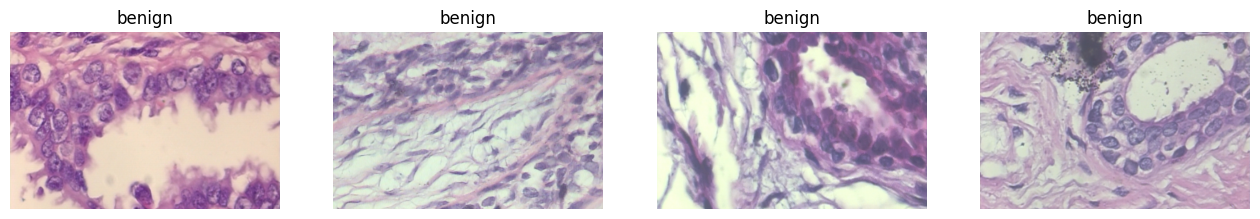

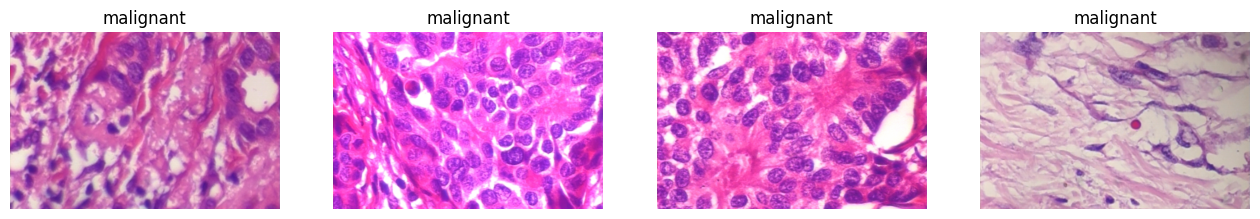

In [6]:
#tampilkan sample
import matplotlib.pyplot as plt
import matplotlib.image as mping

file_train_benign=os.path.join("BreaKHis 400X/train/benign")
file_train_malignant=os.path.join("BreaKHis 400X/train/malignant")

benign_image = os.listdir(file_train_benign)
malignant_image = os.listdir(file_train_malignant)

fname1 = [os.path.join(file_train_benign,fname)
        for fname in benign_image[:4]]

fname2 = [os.path.join(file_train_malignant,fname)
        for fname in malignant_image[:4]]

ncolu = 4
nrow = 2
fig = plt.gcf()
fig.set_size_inches(ncolu*4,nrow*4)
for i,fname in enumerate(fname1):
    sp = plt.subplot(3,4,i+1)
    sp.axis('off')
    img = mping.imread(fname)
    plt.title('benign')
    plt.imshow(img)

plt.show()

ncolu = 4
nrow = 2
fig = plt.gcf()
fig.set_size_inches(ncolu*4,nrow*4)
for i,fname in enumerate(fname2):
    sp = plt.subplot(2,4,i+1)
    sp.axis('off')
    img = mping.imread(fname)
    plt.title('malignant')
    plt.imshow(img)

plt.show()

#### Contoh output kegiatan 1.3

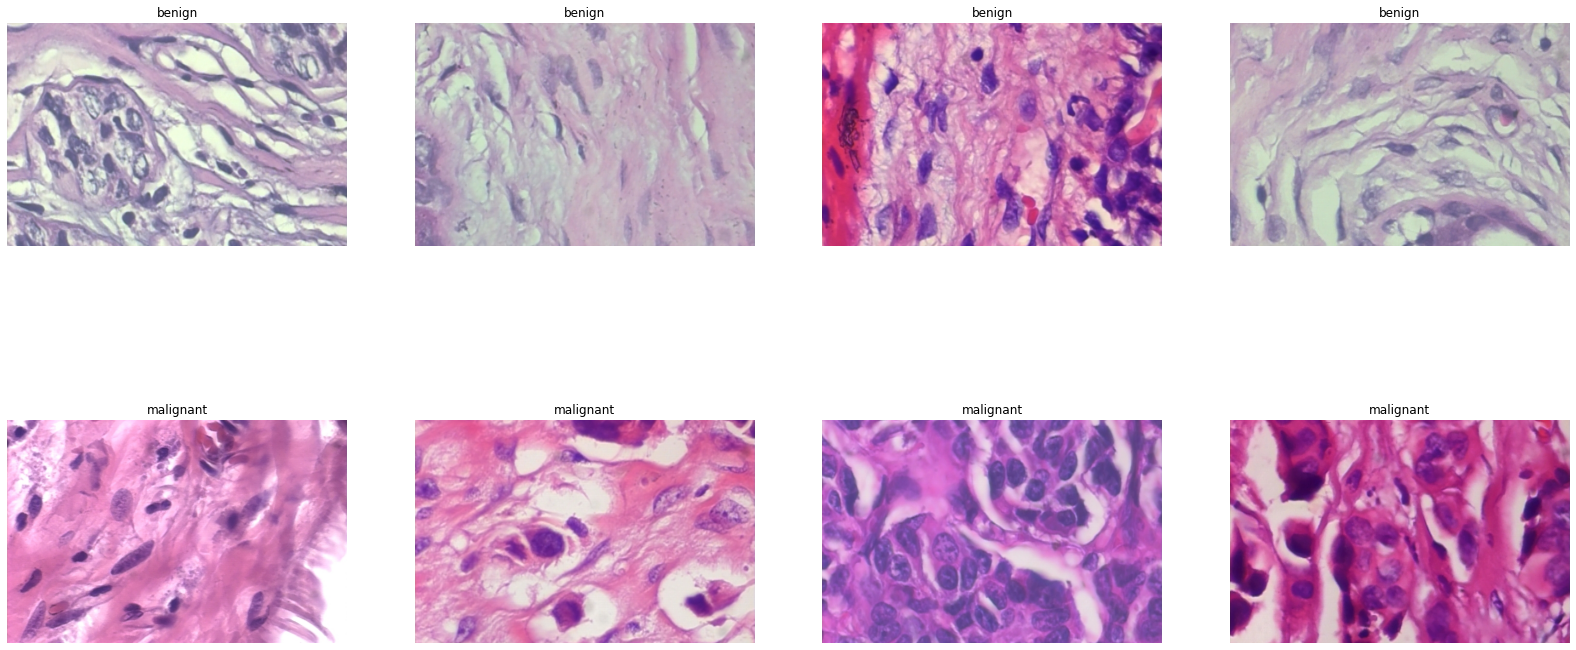

### **2. Preprocessing**

In [7]:
import cv2
import numpy as np

#mengumpulkan data train
train_data = []
train_label = []

train_dir=os.path.join("BreaKHis 400X/train")
for r, d, f in os.walk(train_dir):
    for file in f:
        if ".png" in file:
            imagePath = os.path.join(r, file)
            image = cv2.imread(imagePath)
            image = cv2.resize(image, (250,250))
            train_data.append(image)
            label = imagePath.split(os.path.sep)[-2]
            train_label.append(label)

train_data = np.array(train_data)
train_label = np.array(train_label)

In [8]:
#mengumpulkan data test
test_data = []
test_label = []

testi_dir=os.path.join('BreaKHis 400X/test')
for r, d, f in os.walk(testi_dir):
    for file in f:
        if ".png" in file:
            imagePath = os.path.join(r, file)
            image = cv2.imread(imagePath)
            image = cv2.resize(image, (250,250))
            test_data.append(image)
            label = imagePath.split(os.path.sep)[-2]
            test_label.append(label)

test_data = np.array(test_data)
test_label = np.array(test_label)

In [9]:
print("Train Data = ", train_data.shape)
print("Train Label = ", train_label.shape)
print("Test Data = ", test_data.shape)
print("Test Label = ", test_label.shape)

Train Data =  (1148, 250, 250, 3)
Train Label =  (1148,)
Test Data =  (545, 250, 250, 3)
Test Label =  (545,)


In [10]:
#Normalisasi data
print("Data sebelum di-normalisasi ", train_data[0][0][0])
x_train = train_data.astype('float32') / 255.0
x_test = test_data.astype('float32') / 255.0
print("Data setelah di-normalisasi ", x_train[0][0][0])

Data sebelum di-normalisasi  [177 164 204]
Data setelah di-normalisasi  [0.69411767 0.6431373  0.8       ]


### **2.1 Data Augmentation**
Kita akan mendefinisikan generator untuk melakukan augmentasi gambar secara real-time saat proses training.

In [26]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Mendefinisikan konfigurasi augmentasi
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Fit generator ke data training
train_datagen.fit(x_train)

print("Generator augmentasi berhasil dikonfigurasi.")

Generator augmentasi berhasil dikonfigurasi.


In [11]:
#Label Encoder
from sklearn.preprocessing import LabelEncoder
print("Label sebelum di-encoder ", train_label[200:208])
print("Label sebelum di-encoder ", train_label[400:408])

lb = LabelEncoder()
y_train = lb.fit_transform(train_label)
y_test = lb.fit_transform(test_label)

print("Label setelah di-encoder ", y_train[200:208])
print("Label setelah di-encoder ", y_train[400:408])

Label sebelum di-encoder  ['benign' 'benign' 'benign' 'benign' 'benign' 'benign' 'benign' 'benign']
Label sebelum di-encoder  ['malignant' 'malignant' 'malignant' 'malignant' 'malignant' 'malignant'
 'malignant' 'malignant']
Label setelah di-encoder  [0 0 0 0 0 0 0 0]
Label setelah di-encoder  [1 1 1 1 1 1 1 1]


### **3. Modelling**

In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense, GlobalMaxPooling2D, Conv2D, MaxPool2D, Flatten, AveragePooling2D, GlobalAveragePooling2D

In [13]:
#model scenario pertama
model = Sequential()

model.add(InputLayer(input_shape=[250,250,3]))

#lanjut ke hidden layer
model.add(Conv2D(filters=16, kernel_size=3, strides=1, padding='same', activation='relu'))

model.add(MaxPool2D(pool_size=2, padding='same'))


model.add(Conv2D(filters=32, kernel_size=3, strides=1, padding='same', activation='relu'))

model.add(MaxPool2D(pool_size=2, padding='same'))

model.add(GlobalAveragePooling2D())


model.add(Flatten())


model.add(Dense(512, activation='relu'))

model.add(Dense(256, activation='relu'))

model.add(Dense(128, activation='relu'))

model.add(Dense(2, activation='softmax'))


print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 250, 250, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 125, 125, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 186,466 (728.38 KB)

 Trainable params: 186,466 (728.38 KB)

 Non-trainable params: 0 (0.00 B)

None


In [21]:
# Menjalankan ulang training Model 1 untuk mendapatkan variabel H
from tensorflow.keras.optimizers import Adam

model.compile(optimizer=Adam(),
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

print('Memulai training Model 1...')
H = model.fit(x_train, y_train, batch_size=32, epochs=50, validation_data=(x_test, y_test))

Memulai training Model 1...
Epoch 1/50


KeyboardInterrupt: 

In [20]:
# Mendefinisikan ulang model2 dengan parameter yang benar
model2 = Sequential()
model2.add(InputLayer(shape=[250,250,3]))
model2.add(Conv2D(filters=16, kernel_size=3, strides=1, padding='same', activation='relu'))
model2.add(AveragePooling2D(pool_size=2, padding='same'))
model2.add(Conv2D(filters=32, kernel_size=3, strides=1, padding='same', activation='relu'))
model2.add(AveragePooling2D(pool_size=2, padding='same'))
model2.add(Conv2D(filters=64, kernel_size=3, strides=1, padding='same', activation='relu'))
model2.add(AveragePooling2D(pool_size=2, padding='same'))
model2.add(GlobalMaxPooling2D())
model2.add(Flatten())
model2.add(Dense(512, activation='relu'))
model2.add(Dense(256, activation='relu'))
model2.add(Dense(128, activation='relu'))
model2.add(Dense(1, activation='sigmoid'))

print('Model 2 didefinisikan ulang.')
model2.summary()

Model 2 didefinisikan ulang.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 250, 250, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 125, 125, 16)   │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 63, 63, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 32, 32, 64)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │        33,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221,217 (864.13 KB)

 Trainable params: 221,217 (864.13 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
from tensorflow.keras.optimizers import Adam

# Kompilasi Model 2
model2.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['acc'])

# Melatih Model 2
print('Memulai training Model 2...')
epochs = 50
H2 = model2.fit(x_train, y_train, batch_size=32, epochs=epochs, validation_data=(x_test, y_test))

Memulai training Model 2...
Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 214ms/step - acc: 0.6524 - loss: 0.6551 - val_acc: 0.6771 - val_loss: 0.6248
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - acc: 0.6768 - loss: 0.6223 - val_acc: 0.6771 - val_loss: 0.6192
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - acc: 0.6768 - loss: 0.6092 - val_acc: 0.6771 - val_loss: 0.6033
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - acc: 0.6768 - loss: 0.5848 - val_acc: 0.6771 - val_loss: 0.5663
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - acc: 0.7265 - loss: 0.5271 - val_acc: 0.7761 - val_loss: 0.5116
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - acc: 0.8066 - loss: 0.4746 - val_acc: 0.7615 - val_loss: 0.5106
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - acc: 0.8371 - loss: 0.4382 - val_acc: 0.8147 - val_loss: 0.4614
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - acc: 0.8354 - loss: 0.4273 - val_acc: 0.8404 - val_loss: 0.4431
Epoch 9/50
36/36 ━━━━━━━━━━━━━━━━

### **3.1 Training dengan Augmentasi (Scenario 2)**

In [27]:
# Melatih ulang Model 2 dengan data augmentation
print('Memulai training Model 2 dengan Augmentasi...')
batch_size = 32
H2_aug = model2.fit(
    train_datagen.flow(x_train, y_train, batch_size=batch_size),
    steps_per_epoch=len(x_train) // batch_size,
    epochs=50,
    validation_data=(x_test, y_test)
)

Memulai training Model 2 dengan Augmentasi...
Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 18s 509ms/step - acc: 0.8943 - loss: 0.3001 - val_acc: 0.8587 - val_loss: 0.3282
Epoch 2/50
 1/35 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - acc: 0.8750 - loss: 0.2616

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.8750 - loss: 0.2616 - val_acc: 0.8606 - val_loss: 0.3260
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 19s 540ms/step - acc: 0.8871 - loss: 0.2989 - val_acc: 0.8789 - val_loss: 0.3213
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc: 0.9688 - loss: 0.1885 - val_acc: 0.8716 - val_loss: 0.3242
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 16s 470ms/step - acc: 0.8808 - loss: 0.3013 - val_acc: 0.8587 - val_loss: 0.3675
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.8125 - loss: 0.2878 - val_acc: 0.8771 - val_loss: 0.3306
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 18s 507ms/step - acc: 0.8916 - loss: 0.2876 - val_acc: 0.8679 - val_loss: 0.3976
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.8125 - loss: 0.5476 - val_acc: 0.8587 - val_loss: 0.4077
Epoch 9/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 476ms/step - acc: 0.8889 - loss: 0.3084 - val_acc: 0.8716 - val_loss: 0.3265
Epoch 10/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.8438 -

### **4. Result**

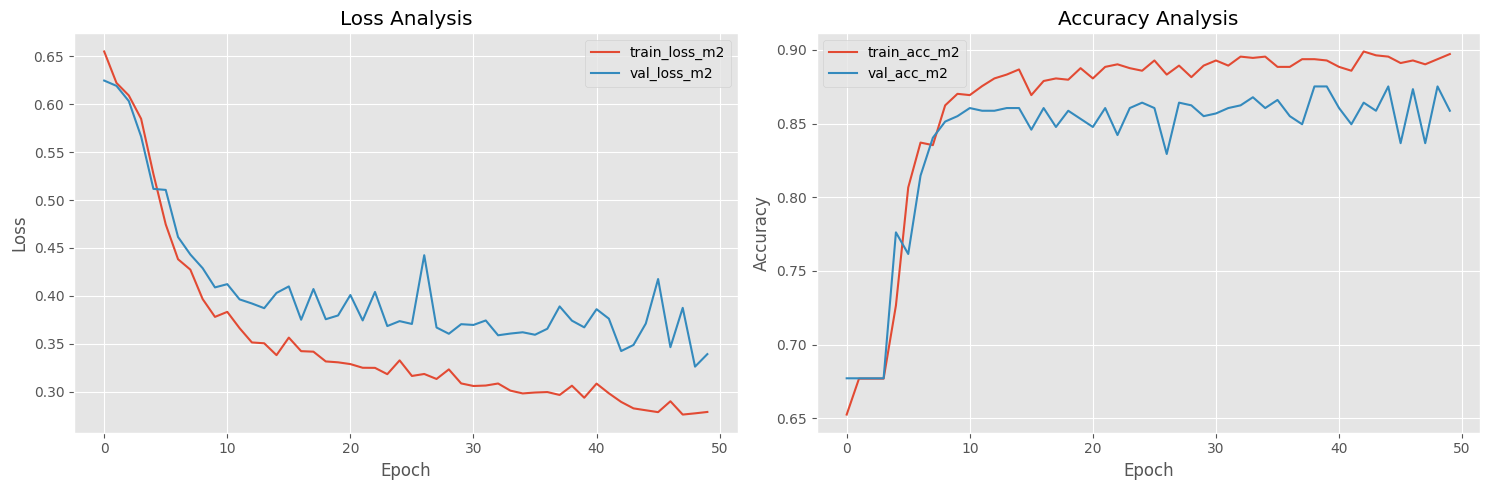

In [23]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# Visualisasi perbandingan Model 1 (H) dan Model 2 (H2)
plt.style.use("ggplot")
plt.figure(figsize=(15, 5))

# Plot Loss
plt.subplot(1, 2, 1)
if 'H' in globals():
    plt.plot(H.history["loss"], label="train_loss_m1", linestyle='--')
    plt.plot(H.history["val_loss"], label="val_loss_m1", linestyle='--')
if 'H2' in globals():
    plt.plot(H2.history["loss"], label="train_loss_m2")
    plt.plot(H2.history["val_loss"], label="val_loss_m2")
plt.title("Loss Analysis")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
if 'H' in globals():
    plt.plot(H.history["acc"], label="train_acc_m1", linestyle='--')
    plt.plot(H.history["val_acc"], label="val_acc_m1", linestyle='--')
if 'H2' in globals():
    plt.plot(H2.history["acc"], label="train_acc_m2")
    plt.plot(H2.history["val_acc"], label="val_acc_m2")
plt.title("Accuracy Analysis")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

### **4.1 Visualisasi Hasil Augmentasi**
Mari kita bandingkan grafik training Model 2 sebelum dan sesudah augmentasi.

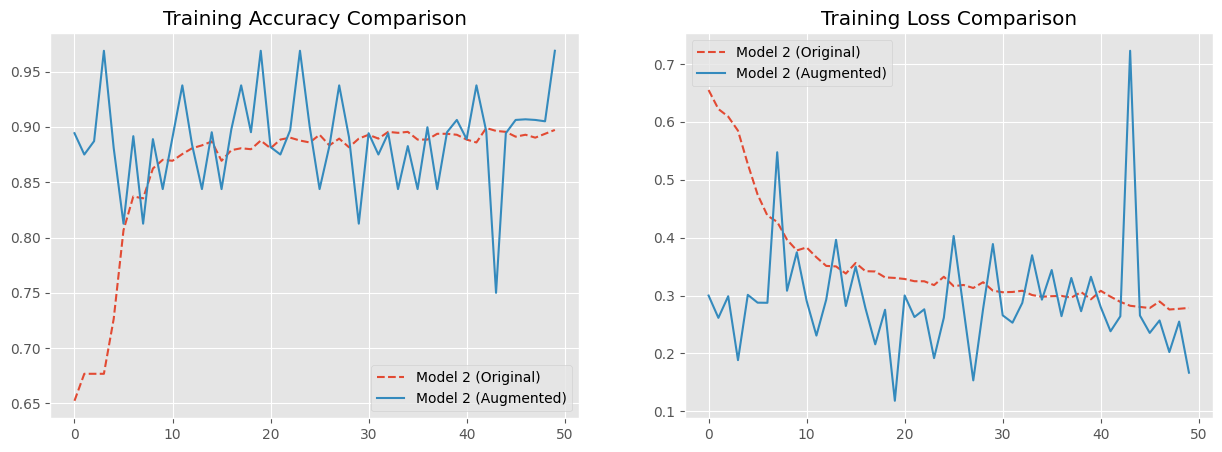

In [28]:
plt.figure(figsize=(15, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(H2.history['acc'], label='Model 2 (Original)', linestyle='--')
plt.plot(H2_aug.history['acc'], label='Model 2 (Augmented)')
plt.title('Training Accuracy Comparison')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(H2.history['loss'], label='Model 2 (Original)', linestyle='--')
plt.plot(H2_aug.history['loss'], label='Model 2 (Augmented)')
plt.title('Training Loss Comparison')
plt.legend()

plt.show()

In [ ]:
from keras.preprocessing.image import img_to_array, array_to_img
from keras.preprocessing import image

img_ = image.load_img("/content/BreaKHis 400X/test/benign/SOB_B_A-14-22549AB-400-001.png", target_size=(250, 250))
imag = image.img_to_array(img_)
imag = np.expand_dims(imag, axis=0)

pred = model.predict(imag)
pred2 = model2.predict(imag)
pred = np.argmax(pred,axis=1)
pred2 = np.argmax(pred2,axis=1)
print("0 for benign,1 for malignant")
print("ini hasil dari model1:",pred)
print("ini hasil dari model2:",pred2)

plt.imshow(img_)

In [24]:
from sklearn.metrics import classification_report
import numpy as np

target_names = ['benign', 'malignant']

# Evaluasi Model 1 (Softmax)
print('Classification Report Model 1:')
pred1 = model.predict(x_test)
labels1 = np.argmax(pred1, axis=1)
print(classification_report(y_test, labels1, target_names=target_names))

# Evaluasi Model 2 (Sigmoid)
print('\nClassification Report Model 2:')
pred2 = model2.predict(x_test)
labels2 = (pred2 > 0.5).astype(int).flatten()
print(classification_report(y_test, labels2, target_names=target_names))

Classification Report Model 1:
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step
              precision    recall  f1-score   support

      benign       0.85      0.68      0.75       176
   malignant       0.86      0.94      0.90       369

    accuracy                           0.86       545
   macro avg       0.85      0.81      0.83       545
weighted avg       0.86      0.86      0.85       545


Classification Report Model 2:
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step
              precision    recall  f1-score   support

      benign       0.81      0.73      0.77       176
   malignant       0.88      0.92      0.90       369

    accuracy                           0.86       545
   macro avg       0.84      0.83      0.83       545
weighted avg       0.86      0.86      0.86       545



In [29]:
print('Classification Report Model 2 (After Augmentation):')
pred2_aug = model2.predict(x_test)
labels2_aug = (pred2_aug > 0.5).astype(int).flatten()
print(classification_report(y_test, labels2_aug, target_names=target_names))

Classification Report Model 2 (After Augmentation):
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
              precision    recall  f1-score   support

      benign       0.90      0.65      0.75       176
   malignant       0.85      0.96      0.90       369

    accuracy                           0.86       545
   macro avg       0.87      0.81      0.83       545
weighted avg       0.87      0.86      0.86       545



### **5. Simpan Model**
Sel berikut akan menyimpan `model` (Scenario 1) dan `model2` (Scenario 2) ke dalam file lokal di Colab. Anda bisa mengunduhnya dari folder di sebelah kiri.

In [25]:
# Menyimpan kedua model untuk deployment
model.save('model_breast_cancer_v1.h5')
model2.save('model_breast_cancer_v2.h5')

print("Model 1 disimpan sebagai: model_breast_cancer_v1.h5")
print("Model 2 disimpan sebagai: model_breast_cancer_v2.h5")
print("Silakan unduh file melalui panel 'Files' di sebelah kiri.")

Model 1 disimpan sebagai: model_breast_cancer_v1.h5
Model 2 disimpan sebagai: model_breast_cancer_v2.h5
Silakan unduh file melalui panel 'Files' di sebelah kiri.


In [33]:
# Menyimpan model versi augmentasi
model2.save('model_breast_cancer_augmented.h5')
print('Model augmented berhasil disimpan sebagai: model_breast_cancer_augmented.h5')
print('Silakan unduh file melalui panel di sebelah kiri.')

Model augmented berhasil disimpan sebagai: model_breast_cancer_augmented.h5
Silakan unduh file melalui panel di sebelah kiri.
